---
title: "Competition Organizers"
subtitle: "Ranking participants and reporting significance with CompStats"
---

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/INGEOTEC/CompStats/blob/main/quarto/pages/competition_organizers.ipynb)

In [ ]:
# Colab does not have CompStats preinstalled
!pip install -q CompStats

This page is aimed at people organizing a competition rather than at a single `sklearn` user: given a gold standard and the predictions submitted by several participants, `CompStats` produces a ranking, confidence intervals for every submission, and p-values for the difference against the best submission -- all from the same paired bootstrap distribution, so the comparisons stay valid even when many participants are involved.

## Dataset

The example uses the gold labels of [INGEOTEC/Delitos](https://github.com/INGEOTEC/Delitos), a corpus of tweets labeled as mentioning a crime (`1`) or not (`0`). Because the tweets' text cannot be redistributed under Twitter/X's terms of service, the published corpus only contains each tweet's id and label; the following cell downloads the test partition and keeps the labels, which play the role of the gold standard an organizer would hold out from the competition's participants.

In [1]:
import json
import urllib.request
import numpy as np

url = ("https://raw.githubusercontent.com/INGEOTEC/Delitos/main/"
       "corpus/delitos_test.json")
with urllib.request.urlopen(url) as fh:
    lines = fh.read().decode('utf-8').splitlines()
y_gold = np.array([json.loads(line)['label'] for line in lines])
y_gold.shape, y_gold.mean()

((360,), np.float64(0.2111111111111111))

## Simulated submissions

With only the labels available (no text to train a real classifier on), five submissions are simulated by flipping the gold label with a different probability per team -- higher skill means fewer flipped labels. Team Alpha and Team Beta share the same skill but flip different labels (a different random seed for each), so their predictions are not identical even though their expected performance is: they are meant to land in a statistical tie for first place. Team Gamma is a step below them but still competitive, and Team Delta and Team Epsilon trail further behind. This mirrors the kind of table an organizer receives: one column per participant, aligned with the same gold standard.

In [2]:
def simulate_submission(y_true, skill, seed):
    """A synthetic participant that mislabels with probability (1 - skill)"""
    rng = np.random.default_rng(seed)
    flip = rng.random(y_true.shape[0]) > skill
    y_pred = y_true.copy()
    y_pred[flip] = 1 - y_pred[flip]
    return y_pred

submissions = {
    'Team Alpha': simulate_submission(y_gold, skill=0.95, seed=0),
    'Team Beta': simulate_submission(y_gold, skill=0.95, seed=7),
    'Team Gamma': simulate_submission(y_gold, skill=0.90, seed=3),
    'Team Delta': simulate_submission(y_gold, skill=0.87, seed=2),
    'Team Epsilon': simulate_submission(y_gold, skill=0.86, seed=9),
}

## Ranking the submissions

`CompStats.metrics.f1_score` follows the `sklearn.metrics` convention -- `(y_true, y_pred)` -- and returns a `Perf` instance instead of a bare float. Passing every submission's predictions, one call per team, builds the comparison and sorts it by performance. The bootstrap resampling draws its indices from NumPy's global random state the first time it runs, so fixing the seed here makes the ranking, the confidence intervals, and the p-values below reproducible across runs of this notebook.

In [3]:
from CompStats.metrics import f1_score

np.random.seed(42)
leaderboard = None
for team, y_pred in submissions.items():
    if leaderboard is None:
        leaderboard = f1_score(y_gold, y_pred, name=team, pos_label=1)
    else:
        leaderboard(y_pred, name=team)
leaderboard

<Perf(func=f1_score)>
Statistic with its standard error (se)
statistic (se)
0.9057 (0.0238) <= Team Beta
0.8554 (0.0296) <= Team Alpha
0.8263 (0.0318) <= Team Gamma
0.7500 (0.0350) <= Team Delta
0.7253 (0.0380) <= Team Epsilon

## Confidence intervals

`Perf.ci` reports the percentile bootstrap confidence interval for every submission's F1 score, so the ranking above can be reported together with a measure of its uncertainty.

In [4]:
leaderboard.ci

{'Team Beta': (np.float64(0.8540010141987829), np.float64(0.9493902439024389)),
 'Team Delta': (np.float64(0.6771539721539722),
  np.float64(0.8111514168658245)),
 'Team Gamma': (np.float64(0.7628125), np.float64(0.8780458698489652)),
 'Team Alpha': (np.float64(0.7963957742272659),
  np.float64(0.9086947456213511)),
 'Team Epsilon': (np.float64(0.6517443762781187),
  np.float64(0.7978723404255319))}

## Significance against the best submission

`Perf.difference` compares every other submission against the best one -- `Team Beta` here -- using the paired bootstrap distribution of the differences, and `Difference.p_value` turns that distribution into a p-value per submission. Team Alpha's p-value stays well above 0.05: it is statistically tied with Team Beta for first place, even though the two teams' predictions are not identical. Team Gamma, Team Delta, and Team Epsilon all trail the top two, but Team Gamma's p-value sits close enough to the 0.05 boundary that, as the next section shows, the conclusion about it can change depending on how the p-values are corrected for testing four submissions against the best one at the same time.

In [5]:
comparison = leaderboard.difference()
comparison

<Difference>
difference p-values  w.r.t Team Beta
0.0000 <= Team Delta
0.0000 <= Team Epsilon
0.0180 <= Team Gamma
0.0880 <= Team Alpha

In [6]:
comparison.p_value()

{'Team Delta': np.float64(0.0),
 'Team Epsilon': np.float64(0.0),
 'Team Gamma': np.float64(0.018),
 'Team Alpha': np.float64(0.088)}

## Correcting for multiple comparisons

Every submission other than the best is tested in the same round, so judging four hypotheses at once against an uncorrected 0.05 threshold inflates the chance that at least one "significant" difference is actually a false positive -- the familywise error rate. `Difference.p_value`'s `correction` argument adjusts for this using any method supported by `statsmodels.stats.multitest.multipletests`; three common choices are `'bonferroni'` (multiplies every p-value by the number of comparisons -- simple and the most conservative of the three), `'holm'` (a step-down version of Bonferroni that is less conservative), and `'fdr_bh'` (Benjamini-Hochberg, which bounds the expected proportion of false positives among the rejected hypotheses rather than the probability of any single false positive, making it the least conservative of the three).

In [7]:
import pandas as pd

pd.DataFrame({
    'raw': comparison.p_value(),
    'bonferroni': comparison.p_value(correction='bonferroni'),
    'holm': comparison.p_value(correction='holm'),
    'fdr_bh': comparison.p_value(correction='fdr_bh'),
})

,raw,bonferroni,holm,fdr_bh
Team Delta,0.000,0.000,0.000,0.000
Team Epsilon,0.000,0.000,0.000,0.000
Team Gamma,0.018,0.072,0.036,0.024
Team Alpha,0.088,0.352,0.088,0.088


Team Gamma's p-value crosses the 0.05 threshold depending on the method: under the raw p-value, Holm, and the FDR correction it stays significantly behind the top two, but Bonferroni's stricter correction is enough to call it statistically tied with them instead. The clear-cut cases are unaffected by the choice: Team Alpha remains tied with Team Beta and Team Delta and Team Epsilon remain clearly behind under every correction.

## Visualizing the comparison

`Perf.plot` and `Difference.plot` color every submission by whether it is the best, tied with the best, or significantly behind it, with confidence intervals computed from the same bootstrap distribution; passing the same `correction` argument used above recomputes that coloring from the corrected p-values.

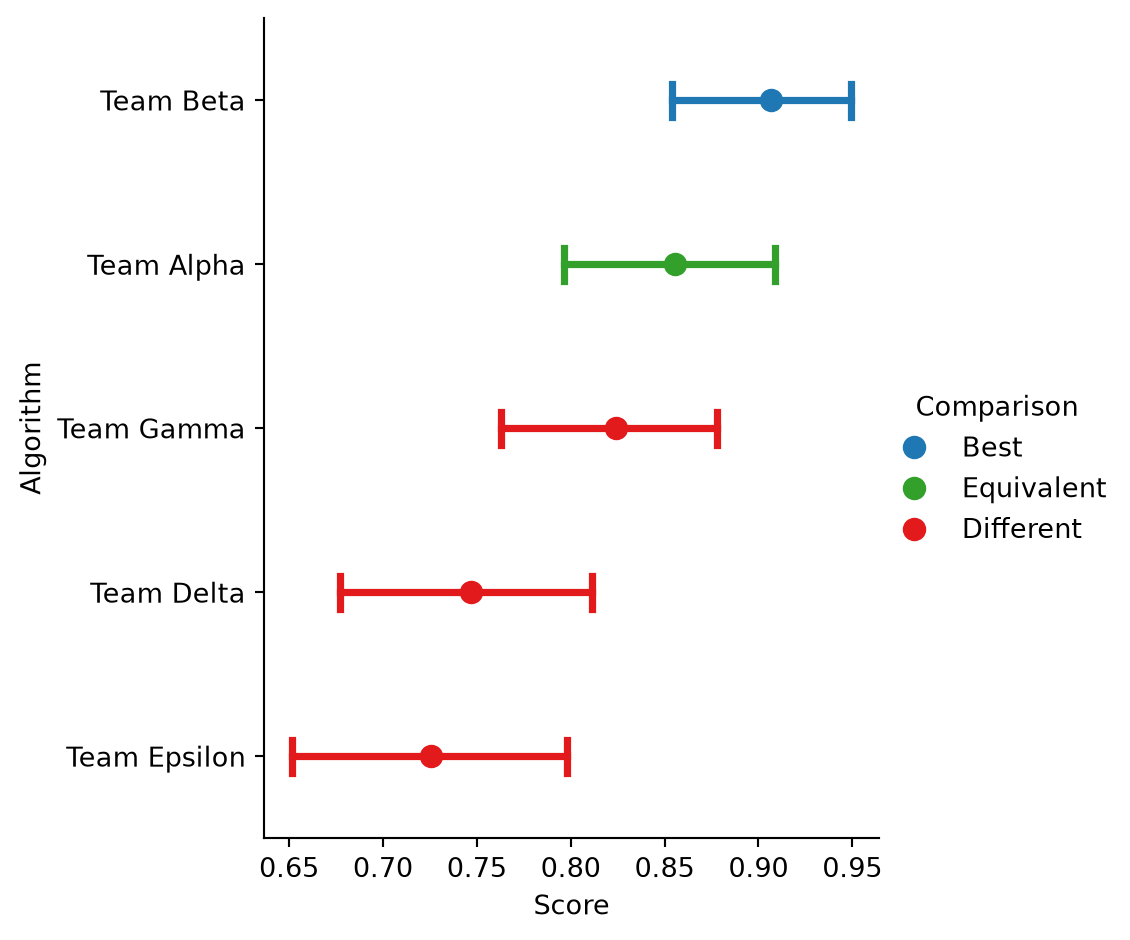

In [8]:
leaderboard.plot()

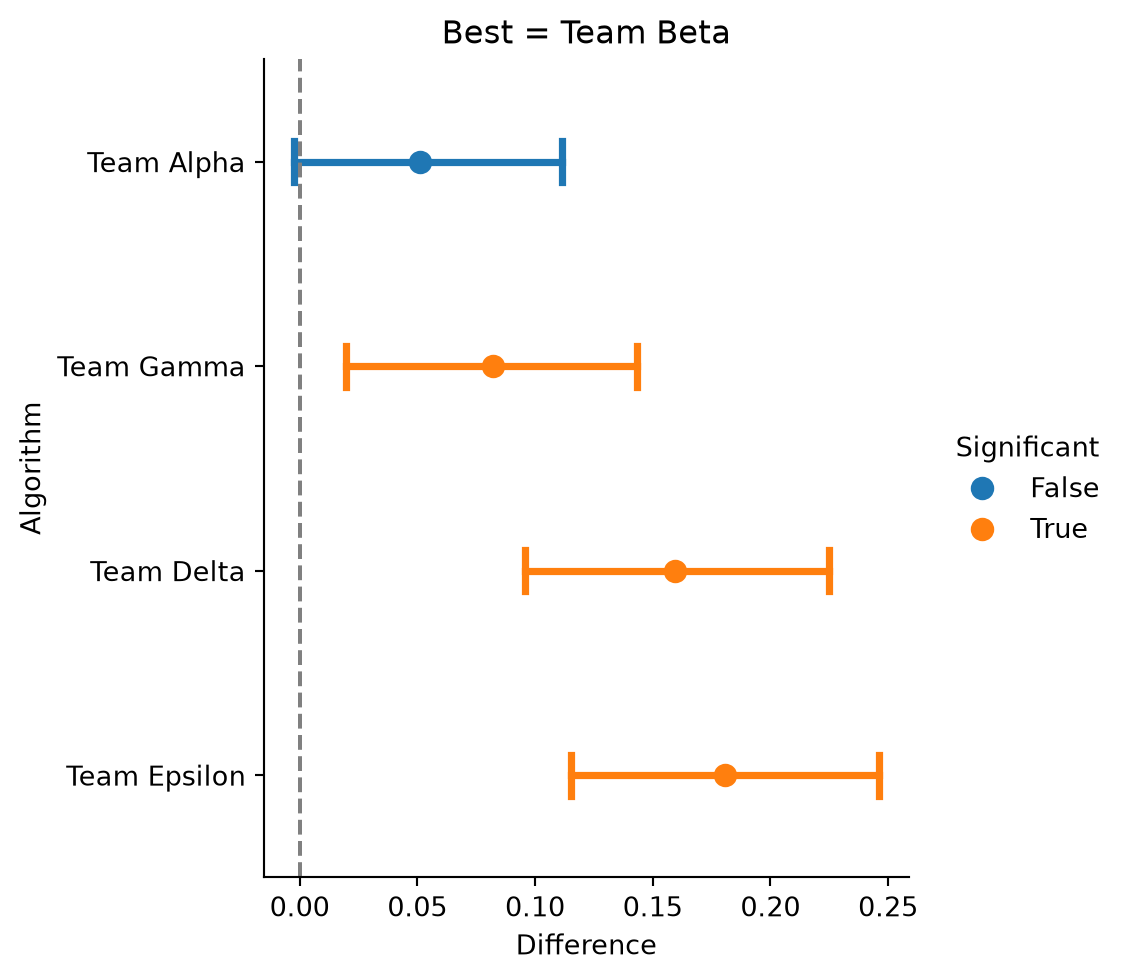

In [9]:
comparison.plot()

Requesting `correction='bonferroni'` recolors Team Gamma from "behind" to "tied" in both plots below, since Bonferroni is the only one of the three corrections that pushes its p-value past 0.05. `'holm'` and `'fdr_bh'` can be passed the same way, but neither changes any submission's color in this comparison -- their corrected p-values for Team Gamma stay under 0.05, so the plots would look identical to the uncorrected ones above.

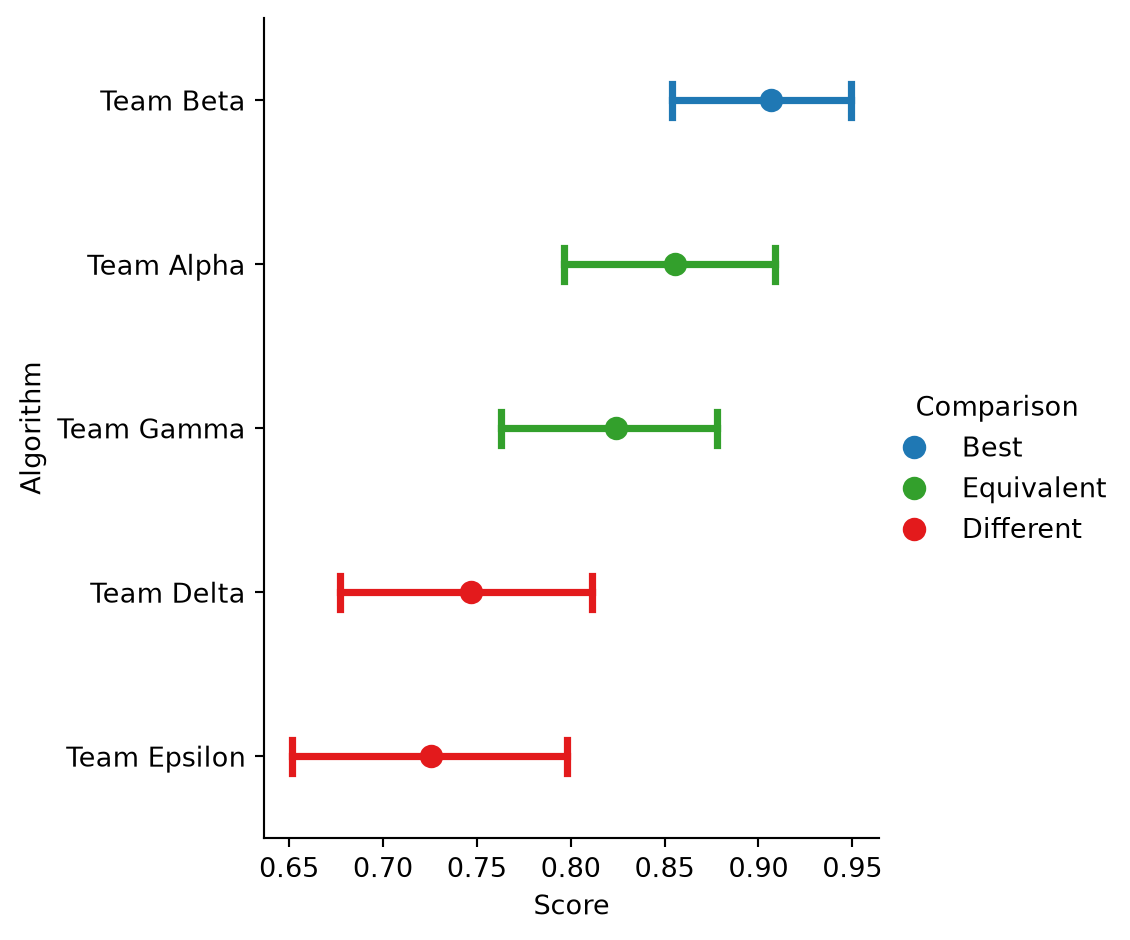

In [10]:
leaderboard.plot(correction='bonferroni')

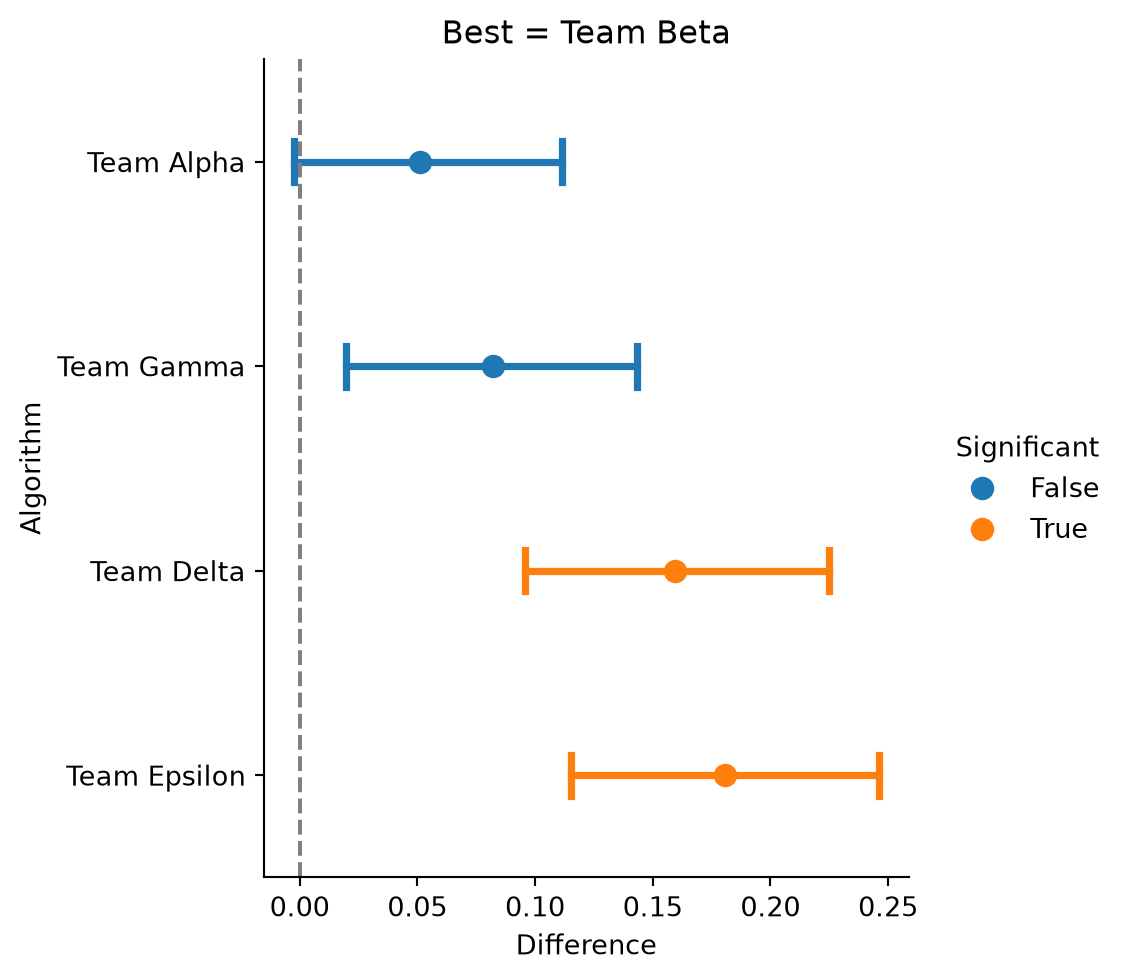

In [11]:
comparison.plot(correction='bonferroni')

[scikit-learn Users](sklearn_users.ipynb) shows the same workflow when comparing a handful of estimators against a single gold standard, and [Multiple Testing](multiple_testing.ipynb) shows how to combine several measures in a single `Perf` and correct their p-values.